In [1]:
import torch

from utils.checkpoints import load_ae_from_path, load_cspn_from_path, load_from_wandb
from utils.visualisation import (
    plot_latent_space,
    show,
)


In [2]:
ae_path = load_from_wandb("autoencoder_celeba")
ae = load_ae_from_path(ae_path, device=torch.device("mps"))

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/jakob/.netrc.


Loading /Users/jakob/Studium/Thesis/master-thesis/artifacts/autoencoder_celeba_beta1.0.pt from Weights & Biases artifact jmartini-tu-darmstadt/master-thesis/autoencoder_celeba:latest


In [3]:
cspn_psi_path = load_from_wandb("cspn_celeba_single_attribute_psinet")
cspn_psi = load_cspn_from_path(cspn_psi_path, device=torch.device("mps"))

Loading /Users/jakob/Studium/Thesis/master-thesis/artifacts/cspn_celeba_single_attribute_psinet.pt from Weights & Biases artifact jmartini-tu-darmstadt/master-thesis/cspn_celeba_single_attribute_psinet:latest
{0, 1}


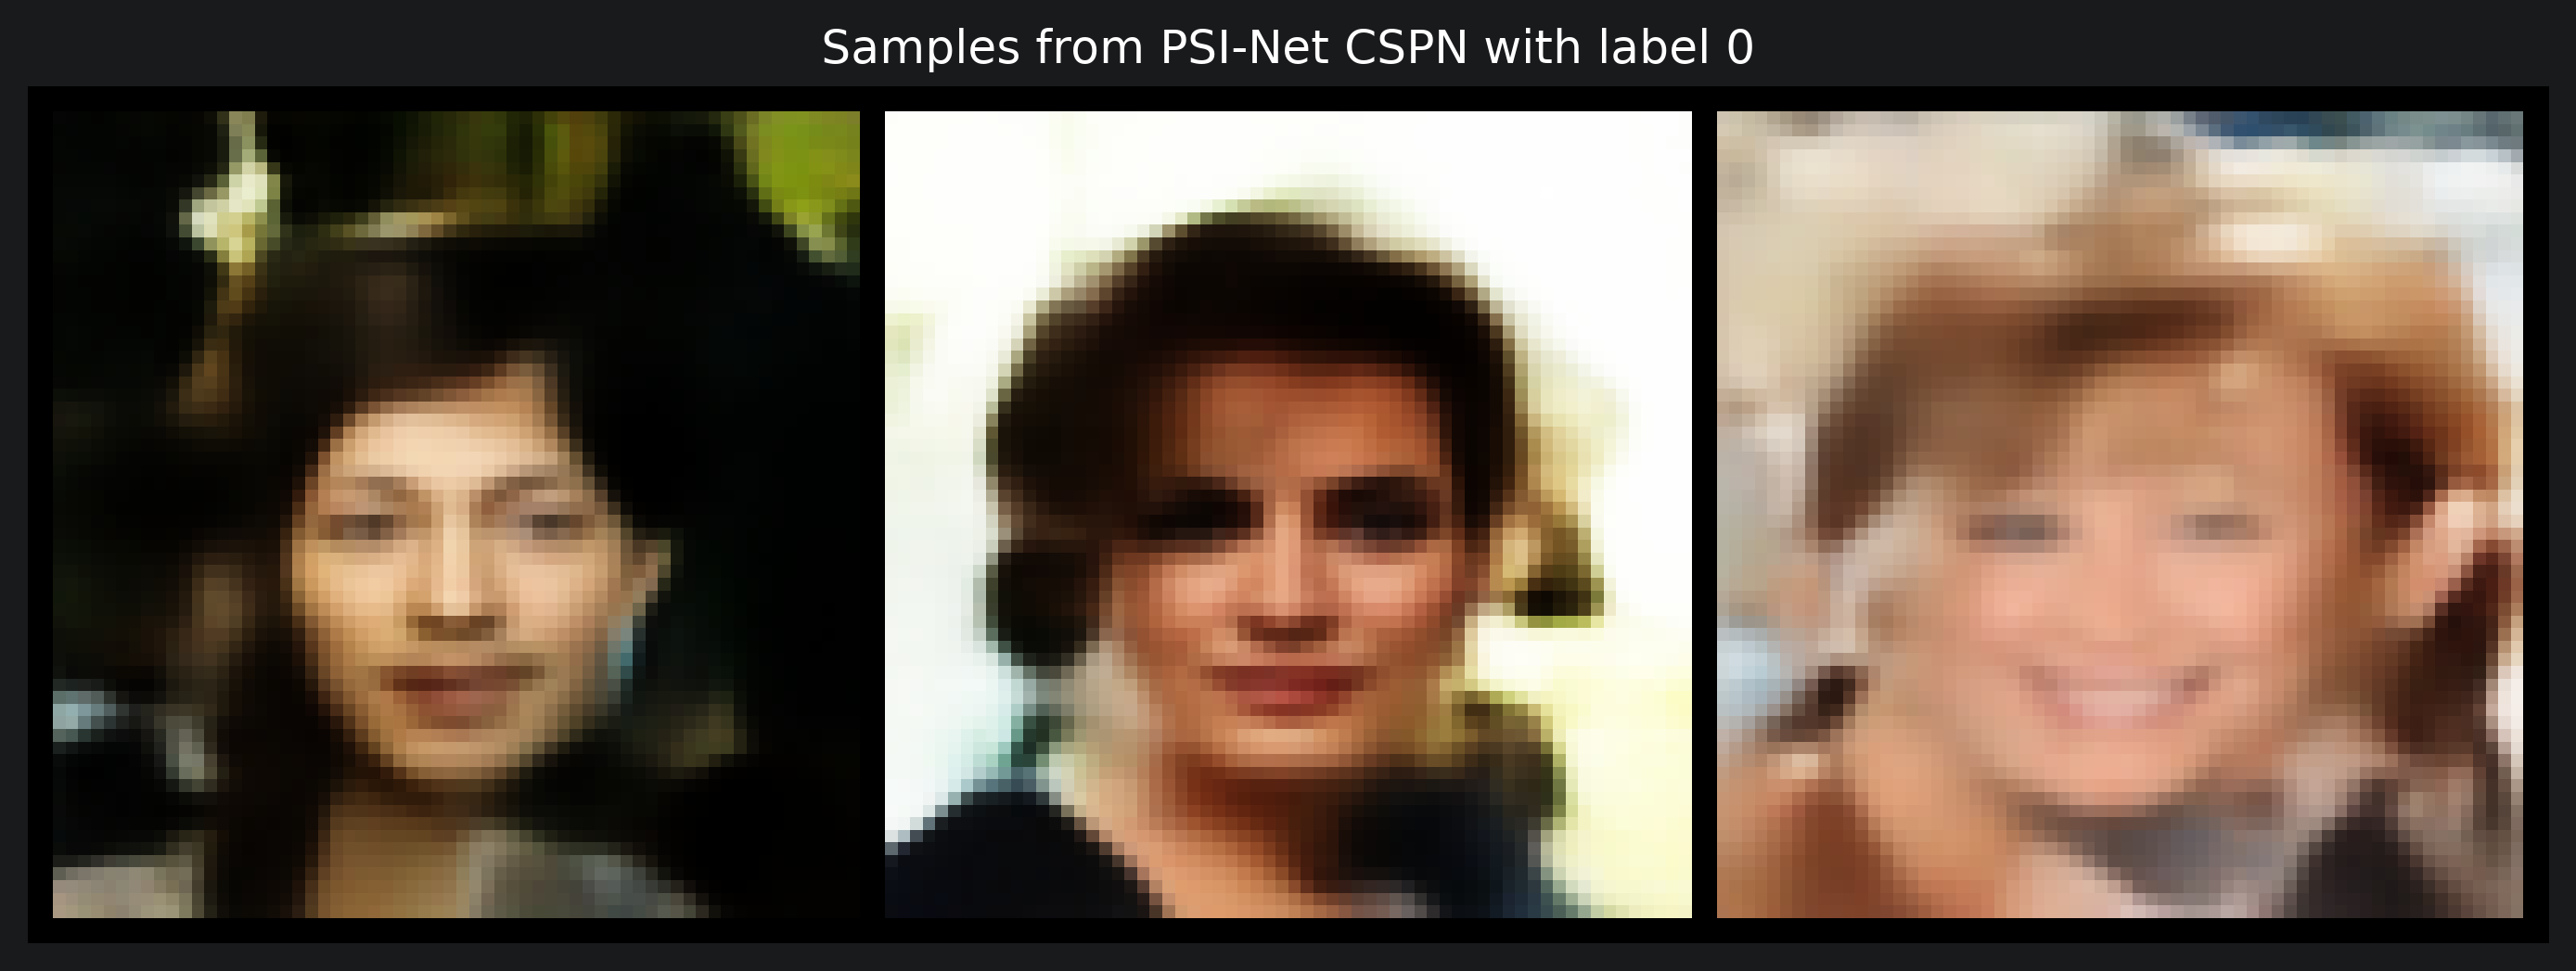

In [20]:
label = 0
sample_labels = torch.tensor([label] * 3)

with torch.no_grad():
    samples_psi = cspn_psi.sample(sample_labels)
    sampled_images_psi_logits = ae.decode(samples_psi)
    sampled_images_psi = torch.sigmoid(sampled_images_psi_logits)

show(sampled_images_psi, f"Samples from PSI-Net CSPN with label {label}")

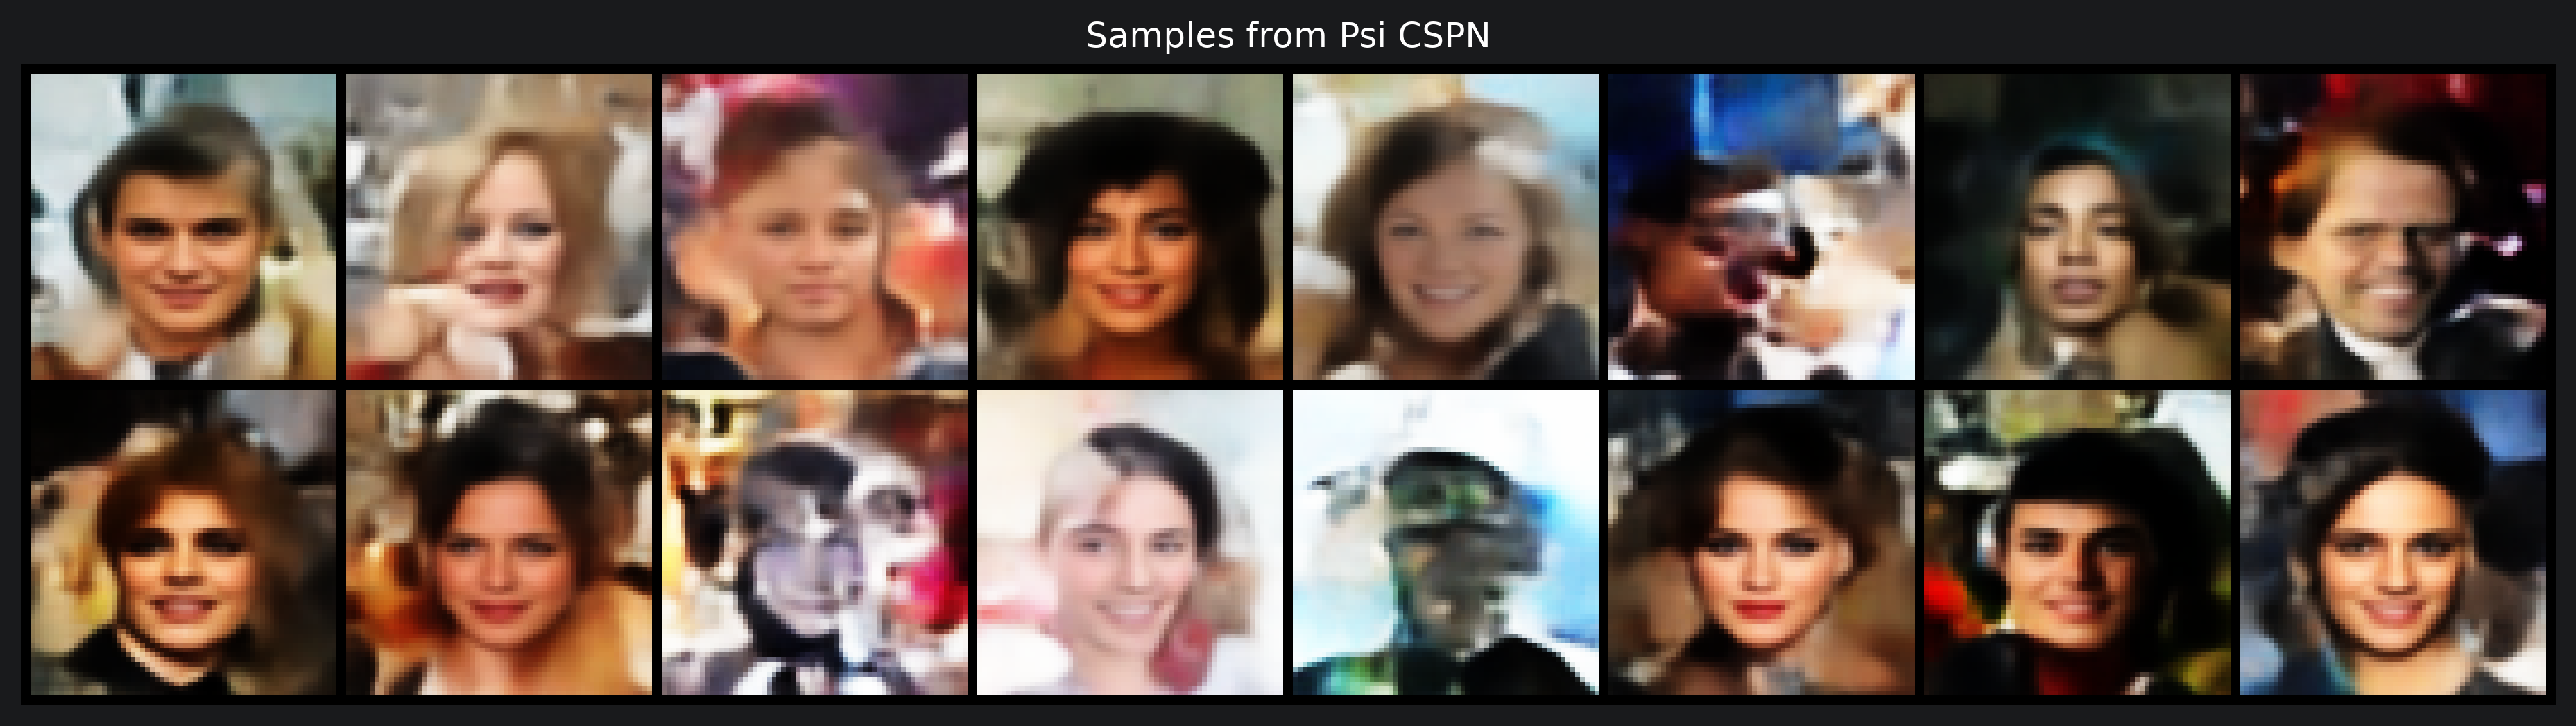

In [36]:
all_labels = torch.arange(2).repeat_interleave(8)

with torch.no_grad():
    samples_psi = cspn_psi.sample(all_labels)
    sampled_images_psi_logits = ae.decode(samples_psi)
    sampled_images_psi = torch.sigmoid(sampled_images_psi_logits)

show(sampled_images_psi, "Samples from Psi CSPN", width=8)

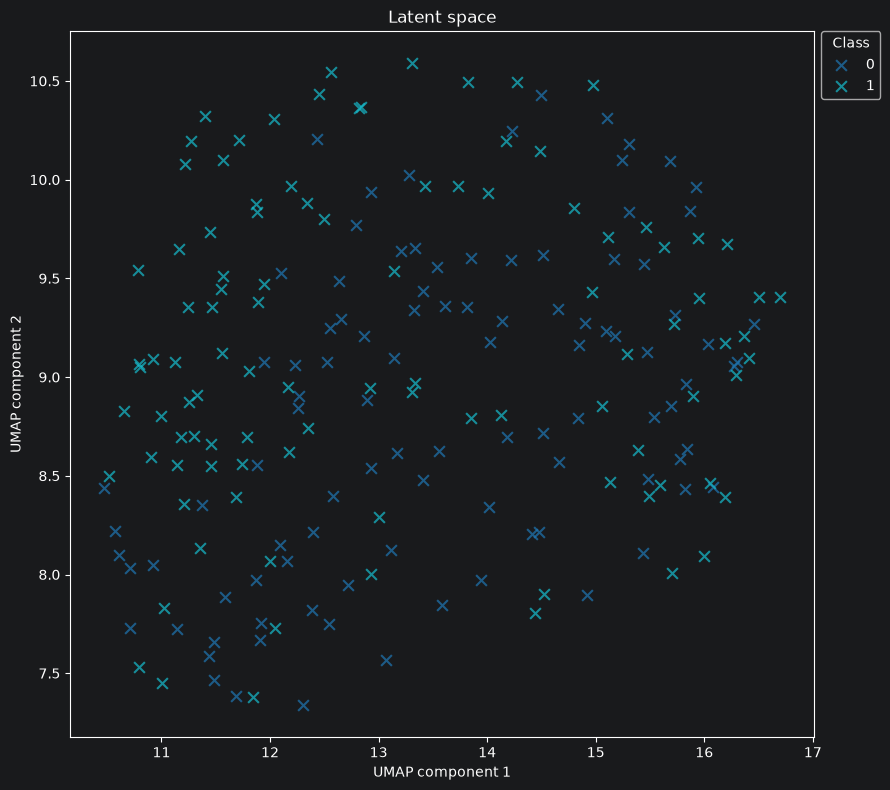

In [37]:
sample_multi_labels = torch.arange(0, 2).repeat_interleave(100)
with torch.no_grad():
    samples_psi = cspn_psi.sample(sample_multi_labels)

plot_latent_space(samples_psi, sample_multi_labels)